11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9110 - loss: 0.2907 - val_accuracy: 0.9823 - val_loss: 0.0523
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9859 - loss: 0.0459 - val_accuracy: 0.9874 - val_loss: 0.0401
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9912 - loss: 0.0272 - val_accuracy: 0.9883 - val_loss: 0.0319
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9890 - val_loss: 0.0312
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9947 - loss: 0.0167 - val_accuracy: 0.9899 - val_loss: 0.0322
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0465
Test accuracy: 0.9898999929428101
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


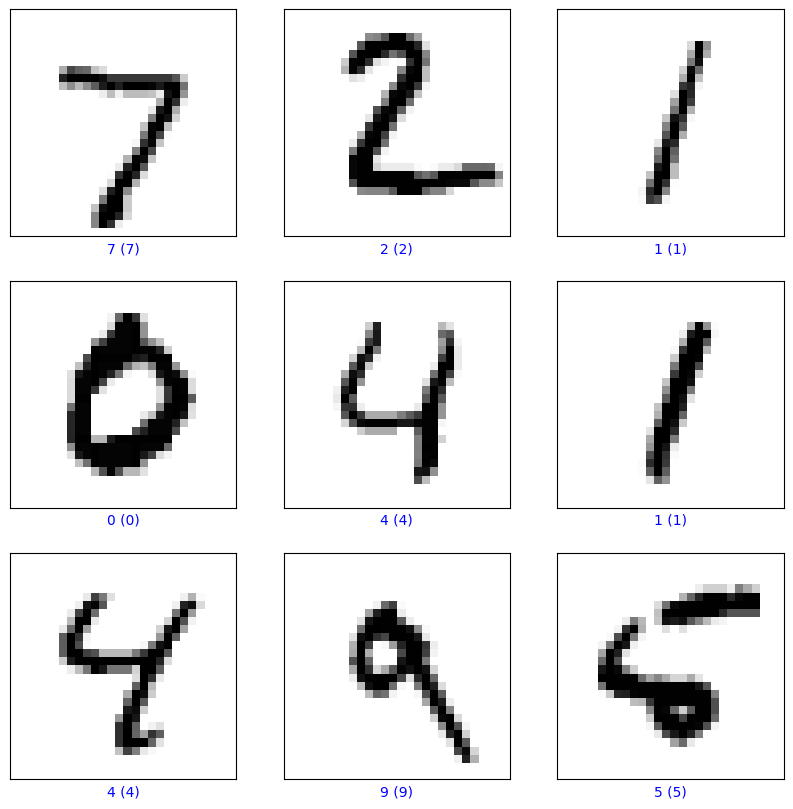

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] range
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape for CNN input (28x28x1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Define CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

# Make predictions
predictions = model.predict(x_test)

def plot_image(i, predictions_array, true_label, img):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(f"{predicted_label} ({true_label})", color=color)

# Display some predictions
num_rows, num_cols = 3, 3
plt.figure(figsize=(10, 10))
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i+1)
    plot_image(i, predictions[i], y_test[i], x_test[i].reshape(28, 28))
plt.show()


In [2]:
!pip install opencv-python
import cv2


In [3]:
def predict_custom_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Load in grayscale
    img = cv2.resize(img, (28, 28))  # Resize to 28x28
    img = img / 255.0  # Normalize pixel values
    img = img.reshape(1, 28, 28, 1)  # Reshape for model input

    prediction = model.predict(img)
    predicted_label = np.argmax(prediction)

    plt.imshow(img.reshape(28, 28), cmap=plt.cm.binary)
    plt.title(f"Predicted: {predicted_label}")
    plt.show()

    return predicted_label


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


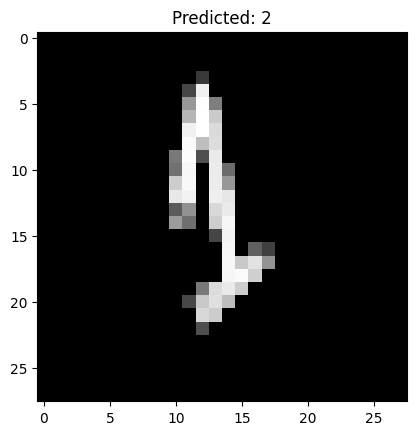

2

In [6]:
predict_custom_image("/content/testimg3.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


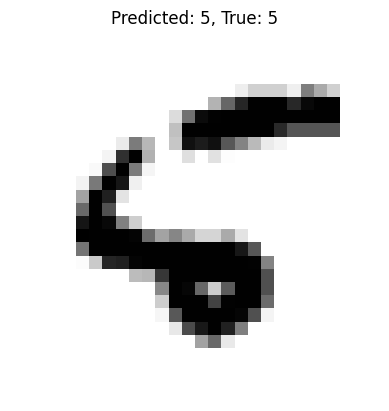

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Function to test an image from the dataset
def test_mnist_image(index):
    img = x_test[index]  # Select image from test set
    true_label = y_test[index]  # Get true label

    # Reshape and predict
    img_input = img.reshape(1, 28, 28, 1)  # Reshape for model
    prediction = model.predict(img_input)
    predicted_label = np.argmax(prediction)  # Get predicted digit

    # Plot the image
    plt.imshow(img.squeeze(), cmap=plt.cm.binary)
    plt.title(f"Predicted: {predicted_label}, True: {true_label}")
    plt.axis('off')
    plt.show()

# Example usage: Test the 5th image in the dataset
test_mnist_image(8)
